# Train encoders — 3 emotions only

Trains audio and video emotion classifiers on **happy**, **angry**, **disgust** only (RAVDESS `emotion_idx` 2, 4, 6). Same pipeline as `02_train_encoders.ipynb`.

In [1]:
!pip install -q transformers wandb

In [2]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: katrinpochtar to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
import gc
import json
import random
import warnings
from functools import partial
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torchaudio
from sklearn.metrics import accuracy_score, f1_score
from torch.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from transformers import (
    Wav2Vec2ForSequenceClassification,
    HubertForSequenceClassification,
    Wav2Vec2FeatureExtractor,
    AutoImageProcessor,
    TimesformerForVideoClassification,
)

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
METADATA = "/content/processed_data/metadata.json"
OUT_DIR = Path("/content/trained_encoders_3emotions")
OUT_DIR.mkdir(parents=True, exist_ok=True)

USE_WANDB = True
WANDB_PROJECT = "uncanny-valley-encoders-3emo"

# Same ordering as 01_data_preprocessing.ipynb EMOTION_TO_IDX
EMOTION_NAME_TO_IDX = {
    "neutral": 0, "calm": 1, "happy": 2, "sad": 3,
    "angry": 4, "fearful": 5, "disgust": 6, "surprised": 7,
}
EMOTIONS = ["happy", "angry", "disgust"]
ALLOWED_EMOTION_IDX = {EMOTION_NAME_TO_IDX[e] for e in EMOTIONS}
REMAP = {EMOTION_NAME_TO_IDX[e]: i for i, e in enumerate(EMOTIONS)}
NUM_EMOTIONS = len(EMOTIONS)
LABEL_SMOOTHING = 0.1

print(f"Device: {DEVICE}")
print(f"Classes: {NUM_EMOTIONS}, Emotions: {EMOTIONS}")
print(f"RAVDESS emotion_idx: {sorted(ALLOWED_EMOTION_IDX)} -> labels 0..{NUM_EMOTIONS-1}")

Device: cuda
Classes: 3, Emotions: ['happy', 'angry', 'disgust']
RAVDESS emotion_idx: [2, 4, 6] -> labels 0..2


In [4]:
class EmotionDataset(Dataset):
    def __init__(self, metadata_path, split, modality):
        with open(metadata_path) as f:
            data = json.load(f)
        self.samples = [
            s for s in data
            if s["split"] == split and s["emotion_idx"] in ALLOWED_EMOTION_IDX
        ]
        self.modality = modality

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        item = {"emotion": REMAP[s["emotion_idx"]]}
        if self.modality == "audio":
            wav, _ = torchaudio.load(s["audio_path"])
            item["audio"] = wav.squeeze(0)
        else:
            frames = np.load(s["frames_path"])
            item["video"] = torch.from_numpy(frames).permute(0, 3, 1, 2).float() / 255.0
        return item


def collate_fn(batch):
    out = {"emotion": torch.tensor([b["emotion"] for b in batch])}
    if "audio" in batch[0]:
        out["audio"] = [b["audio"] for b in batch]
    if "video" in batch[0]:
        out["video"] = torch.stack([b["video"] for b in batch])
    return out

In [5]:
def crop_audio(wav, sr, duration, train):
    L = int(round(duration * sr))
    n = wav.numel()
    if n <= L:
        return torch.nn.functional.pad(wav, (0, L - n))
    start = torch.randint(0, n - L + 1, ()).item() if train else (n - L) // 2
    return wav[start:start + L]


def crop_video(video, n_frames, train):
    T = video.shape[0]
    if T <= n_frames:
        idx = torch.linspace(0, T - 1, n_frames).round().long()
        return video[idx]
    start = torch.randint(0, T - n_frames + 1, ()).item() if train else (T - n_frames) // 2
    return video[start:start + n_frames]


def prepare_audio(batch, processor, window_s, device, train=True):
    sr = 16000
    wavs = [crop_audio(a, sr, window_s, train).numpy() for a in batch["audio"]]
    enc = processor(wavs, sampling_rate=sr, return_tensors="pt", padding=True,
                    truncation=True, max_length=int(window_s * sr))
    kwargs = {"input_values": enc["input_values"].to(device)}
    if "attention_mask" in enc:
        kwargs["attention_mask"] = enc["attention_mask"].to(device)
    return kwargs, batch["emotion"].to(device)


def prepare_video(batch, processor, n_frames, device, train=True):
    clips = []
    for v in batch["video"]:
        clip = crop_video(v, n_frames, train)
        clips.append([clip[i].permute(1, 2, 0).numpy() for i in range(clip.shape[0])])
    enc = processor(clips, return_tensors="pt", do_rescale=False)
    return {"pixel_values": enc["pixel_values"].to(device)}, batch["emotion"].to(device)

In [6]:
def train_one_epoch(model, loader, prep_fn, optimizer, scaler, loss_fn):
    model.train()
    total_loss, preds, labels = 0.0, [], []
    for batch in tqdm(loader, leave=False):
        kwargs, y = prep_fn(batch, train=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda", enabled=DEVICE == "cuda"):
            logits = model(**kwargs).logits
            loss = loss_fn(logits, y)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        preds.extend(logits.argmax(1).detach().cpu().tolist())
        labels.extend(y.cpu().tolist())
    return {
        "loss": total_loss / len(loader),
        "acc": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted"),
    }


@torch.no_grad()
def evaluate(model, loader, prep_fn, loss_fn):
    model.eval()
    total_loss, preds, labels = 0.0, [], []
    for batch in tqdm(loader, leave=False):
        kwargs, y = prep_fn(batch, train=False)
        with autocast("cuda", enabled=DEVICE == "cuda"):
            logits = model(**kwargs).logits
            loss = loss_fn(logits, y)
        total_loss += loss.item()
        preds.extend(logits.argmax(1).cpu().tolist())
        labels.extend(y.cpu().tolist())
    return {
        "loss": total_loss / len(loader),
        "acc": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted"),
    }

In [7]:
def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def run_experiment(cfg):
    seed_all()
    name, modality = cfg["name"], cfg["modality"]
    print(f"{'='*60}\n{name}\n{'='*60}")

    if USE_WANDB:
        wandb.init(project=WANDB_PROJECT, name=name,
                   group=modality, config={**cfg, "emotions": EMOTIONS}, reinit=True)

    train_ds = EmotionDataset(METADATA, "train", modality)
    val_ds = EmotionDataset(METADATA, "val", modality)
    bs = cfg.get("batch_size", 8)
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True,
                              num_workers=0, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=bs, shuffle=False,
                            num_workers=0, collate_fn=collate_fn)

    if modality == "audio":
        model_cls = (HubertForSequenceClassification if "hubert" in cfg["model"].lower()
                     else Wav2Vec2ForSequenceClassification)
        model = model_cls.from_pretrained(
            cfg["model"], num_labels=NUM_EMOTIONS, ignore_mismatched_sizes=True)
        processor = Wav2Vec2FeatureExtractor.from_pretrained(cfg["model"])
        prep_fn = partial(prepare_audio, processor=processor,
                          window_s=cfg.get("window_s", 3.0), device=DEVICE)
        if hasattr(model, "freeze_feature_encoder"):
            model.freeze_feature_encoder()
    else:
        model = TimesformerForVideoClassification.from_pretrained(
            cfg["model"], num_labels=NUM_EMOTIONS, ignore_mismatched_sizes=True)
        processor = AutoImageProcessor.from_pretrained(cfg["model"])
        prep_fn = partial(prepare_video, processor=processor,
                          n_frames=cfg.get("n_frames", 8), device=DEVICE)
        for n, p in model.named_parameters():
            if "classifier" not in n:
                p.requires_grad = False

    model.to(DEVICE)
    loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=cfg["lr"])
    scaler = GradScaler(enabled=DEVICE == "cuda")
    scheduler = None

    best_f1, patience_cnt = 0.0, 0
    save_path = OUT_DIR / name

    for epoch in range(cfg["epochs"]):
        freeze_ep = cfg.get("freeze_epochs", 2)
        if epoch == freeze_ep:
            for p in model.parameters():
                p.requires_grad = True
            unfreeze_lr = cfg["lr"] if freeze_ep == 0 else cfg["lr"] * 0.1
            optimizer = torch.optim.AdamW(model.parameters(), lr=unfreeze_lr)
            scaler = GradScaler(enabled=DEVICE == "cuda")
            scheduler = CosineAnnealingLR(
                optimizer, T_max=cfg["epochs"] - epoch, eta_min=1e-7)

        t = train_one_epoch(model, train_loader, prep_fn, optimizer, scaler, loss_fn)
        v = evaluate(model, val_loader, prep_fn, loss_fn)

        if scheduler:
            scheduler.step()

        if USE_WANDB:
            wandb.log({
                "epoch": epoch + 1,
                "train/loss": t["loss"], "train/acc": t["acc"], "train/f1": t["f1"],
                "val/loss": v["loss"], "val/acc": v["acc"], "val/f1": v["f1"],
                "lr": optimizer.param_groups[0]["lr"],
            })
        print(f"  [{epoch+1:2d}/{cfg['epochs']}] "
              f"t_f1={t['f1']:.3f} v_f1={v['f1']:.3f} v_loss={v['loss']:.3f}")

        if v["f1"] > best_f1:
            best_f1 = v["f1"]
            save_path.mkdir(parents=True, exist_ok=True)
            model.save_pretrained(str(save_path))
            processor.save_pretrained(str(save_path))
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= cfg.get("patience", 5):
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if USE_WANDB:
        wandb.log({"best_val_f1": best_f1})
        wandb.finish()
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    print(f"  Best F1: {best_f1:.4f} -> {save_path}\n")
    return {"name": name, "best_f1": best_f1, "path": str(save_path), "modality": modality}

In [8]:
P = "3emo-"
EXPERIMENTS = [
    {"name": f"{P}w2v2-er-lr3e5", "modality": "audio",
     "model": "superb/wav2vec2-base-superb-er",
     "lr": 3e-5, "window_s": 3.0, "batch_size": 8,
     "epochs": 50, "freeze_epochs": 2, "patience": 8},
    {"name": f"{P}w2v2-er-lr5e5", "modality": "audio",
     "model": "superb/wav2vec2-base-superb-er",
     "lr": 5e-5, "window_s": 3.0, "batch_size": 8,
     "epochs": 50, "freeze_epochs": 2, "patience": 8},
    {"name": f"{P}w2v2-er-lr1e4", "modality": "audio",
     "model": "superb/wav2vec2-base-superb-er",
     "lr": 1e-4, "window_s": 3.0, "batch_size": 8,
     "epochs": 50, "freeze_epochs": 2, "patience": 8},
    {"name": f"{P}w2v2-er-lr5e5-w5", "modality": "audio",
     "model": "superb/wav2vec2-base-superb-er",
     "lr": 5e-5, "window_s": 5.0, "batch_size": 8,
     "epochs": 50, "freeze_epochs": 2, "patience": 8},
    {"name": f"{P}hubert-er-lr3e5", "modality": "audio",
     "model": "superb/hubert-base-superb-er",
     "lr": 3e-5, "window_s": 3.0, "batch_size": 8,
     "epochs": 50, "freeze_epochs": 2, "patience": 8},
    {"name": f"{P}hubert-er-lr5e5", "modality": "audio",
     "model": "superb/hubert-base-superb-er",
     "lr": 5e-5, "window_s": 3.0, "batch_size": 8,
     "epochs": 50, "freeze_epochs": 2, "patience": 8},
    {"name": f"{P}hubert-er-lr1e4", "modality": "audio",
     "model": "superb/hubert-base-superb-er",
     "lr": 1e-4, "window_s": 3.0, "batch_size": 8,
     "epochs": 50, "freeze_epochs": 2, "patience": 8},
    {"name": f"{P}hubert-er-lr5e5-w5", "modality": "audio",
     "model": "superb/hubert-base-superb-er",
     "lr": 5e-5, "window_s": 5.0, "batch_size": 8,
     "epochs": 50, "freeze_epochs": 2, "patience": 8},
    {"name": f"{P}w2v2-lg-lr2e5", "modality": "audio",
     "model": "facebook/wav2vec2-large",
     "lr": 2e-5, "window_s": 3.0, "batch_size": 4,
     "epochs": 40, "freeze_epochs": 3, "patience": 7},
    {"name": f"{P}hubert-lg-lr2e5", "modality": "audio",
     "model": "facebook/hubert-large-ll60k",
     "lr": 2e-5, "window_s": 3.0, "batch_size": 4,
     "epochs": 40, "freeze_epochs": 3, "patience": 7},
    {"name": f"{P}tsf-lr1e5-16f", "modality": "video",
     "model": "facebook/timesformer-base-finetuned-k400",
     "lr": 1e-5, "n_frames": 16, "batch_size": 2,
     "epochs": 30, "freeze_epochs": 1, "patience": 7},
    {"name": f"{P}tsf-lr3e5-16f", "modality": "video",
     "model": "facebook/timesformer-base-finetuned-k400",
     "lr": 3e-5, "n_frames": 16, "batch_size": 2,
     "epochs": 30, "freeze_epochs": 1, "patience": 7},
    {"name": f"{P}tsf-lr5e5-16f", "modality": "video",
     "model": "facebook/timesformer-base-finetuned-k400",
     "lr": 5e-5, "n_frames": 16, "batch_size": 2,
     "epochs": 30, "freeze_epochs": 1, "patience": 7},
    {"name": f"{P}tsf-lr3e5-16f-nf", "modality": "video",
     "model": "facebook/timesformer-base-finetuned-k400",
     "lr": 3e-5, "n_frames": 16, "batch_size": 2,
     "epochs": 30, "freeze_epochs": 0, "patience": 7},
    {"name": f"{P}tsf-lr3e5-8f", "modality": "video",
     "model": "facebook/timesformer-base-finetuned-k400",
     "lr": 3e-5, "n_frames": 8, "batch_size": 4,
     "epochs": 30, "freeze_epochs": 1, "patience": 7},
    {"name": f"{P}tsf-lr1e5-16f-f3", "modality": "video",
     "model": "facebook/timesformer-base-finetuned-k400",
     "lr": 1e-5, "n_frames": 16, "batch_size": 2,
     "epochs": 30, "freeze_epochs": 3, "patience": 7},
]

In [9]:
results = []
for exp in EXPERIMENTS:
    results.append(run_experiment(exp))

3emo-w2v2-er-lr3e5


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

...

  [12/30] t_f1=0.993 v_f1=0.875 v_loss=0.503


  [13/30] t_f1=0.993 v_f1=0.875 v_loss=0.493


  [14/30] t_f1=0.998 v_f1=0.875 v_loss=0.484
  Early stopping at epoch 14


best_val_f1,▁
epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
lr,███▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▃▄▆██████████
train/f1,▁▃▅▇██████████
train/loss,█▇▇▅▂▂▁▁▁▁▁▁▁▁
val/acc,▁▄▄▇▆▇██▇▇▇▇▇▇
val/f1,▁▄▄▇▆▇██▇▇▇▇▇▇
val/loss,█▇▆▃▂▂▁▁▁▁▁▁▁▁
best_val_f1,0.90332
epoch,14


  Best F1: 0.9033 -> /content/trained_encoders_3emotions/3emo-tsf-lr1e5-16f-f3



In [10]:
print(f"\n{'='*60}")
print("RESULTS SUMMARY")
print(f"{'='*60}")
print(f"{'Name':35s} {'Modality':>8s} {'Best Val F1':>12s}")
print("-" * 58)
for r in sorted(results, key=lambda x: -x["best_f1"]):
    print(f"{r['name']:35s} {r['modality']:>8s} {r['best_f1']:12.4f}")

best_audio = max((r for r in results if r["modality"] == "audio"), key=lambda x: x["best_f1"])
best_video = max((r for r in results if r["modality"] == "video"), key=lambda x: x["best_f1"])
print(f"\nBest audio: {best_audio['name']} (F1={best_audio['best_f1']:.4f})")
print(f"Best video: {best_video['name']} (F1={best_video['best_f1']:.4f})")


RESULTS SUMMARY
Name                                Modality  Best Val F1
----------------------------------------------------------
3emo-tsf-lr3e5-16f-nf                  video       0.9861
3emo-tsf-lr5e5-16f                     video       0.9722
3emo-tsf-lr3e5-16f                     video       0.9719
3emo-hubert-er-lr3e5                   audio       0.9450
3emo-w2v2-er-lr5e5-w5                  audio       0.9300
3emo-w2v2-er-lr3e5                     audio       0.9162
3emo-tsf-lr1e5-16f-f3                  video       0.9033
3emo-hubert-lg-lr2e5                   audio       0.8892
3emo-w2v2-er-lr5e5                     audio       0.8880
3emo-tsf-lr3e5-8f                      video       0.8766
3emo-hubert-er-lr5e5                   audio       0.8754
3emo-tsf-lr1e5-16f                     video       0.8754
3emo-w2v2-er-lr1e4                     audio       0.8753
3emo-hubert-er-lr5e5-w5                audio       0.8743
3emo-w2v2-lg-lr2e5                     audio       0.8

In [13]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [11]:
@torch.no_grad()
def collect_predictions(model, loader, prep_fn):
    model.eval()
    all_preds, all_labels, all_losses = [], [], []
    for batch in loader:
        kwargs, y = prep_fn(batch, train=False)
        with autocast("cuda", enabled=DEVICE == "cuda"):
            logits = model(**kwargs).logits
            loss = nn.CrossEntropyLoss(reduction="none")(logits, y)
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(y.cpu().tolist())
        all_losses.extend(loss.cpu().tolist())
    return np.array(all_preds), np.array(all_labels), np.array(all_losses)


def per_emotion_report(preds, labels, losses, title):
    import matplotlib.pyplot as plt
    import seaborn as sns

    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}\n")
    print(classification_report(labels, preds, target_names=EMOTIONS, digits=3, zero_division=0))

    per_f1 = f1_score(labels, preds, average=None,
                      labels=list(range(NUM_EMOTIONS)), zero_division=0)
    cm = confusion_matrix(labels, preds, labels=list(range(NUM_EMOTIONS)))

    print(f"{'Emotion':<12s} {'N':>5s} {'Acc':>6s} {'F1':>6s} {'AvgLoss':>8s}")
    print("-" * 40)
    for i, emo in enumerate(EMOTIONS):
        mask = labels == i
        n = mask.sum()
        if n == 0:
            continue
        acc = (preds[mask] == i).mean()
        avg_loss = losses[mask].mean()
        print(f"{emo:<12s} {n:5d} {acc:6.3f} {per_f1[i]:6.3f} {avg_loss:8.3f}")

    worst = np.argsort(per_f1)
    print(f"\nWeakest: ", end="")
    print(" < ".join(f"{EMOTIONS[i]} ({per_f1[i]:.3f})" for i in worst[:3]))

    fig, ax = plt.subplots(figsize=(8, 6))
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_norm = cm / row_sums
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax,
                vmin=0, vmax=1, linewidths=0.5)
    for i in range(NUM_EMOTIONS):
        for j in range(NUM_EMOTIONS):
            if cm[i, j] > 0:
                ax.text(j + 0.5, i + 0.72, f"({cm[i,j]})",
                        ha="center", va="center", fontsize=7, color="gray")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return per_f1

Evaluating: 3emo-hubert-er-lr3e5 (F1=0.9450)

  AUDIO — 3emo-hubert-er-lr3e5

              precision    recall  f1-score   support

       happy      1.000     0.958     0.979        24
       angry      1.000     0.875     0.933        24
     disgust      0.857     1.000     0.923        24

    accuracy                          0.944        72
   macro avg      0.952     0.944     0.945        72
weighted avg      0.952     0.944     0.945        72

Emotion          N    Acc     F1  AvgLoss
----------------------------------------
happy           24  0.958  0.979    0.160
angry           24  0.875  0.933    0.397
disgust         24  1.000  0.923    0.310

Weakest: disgust (0.923) < angry (0.933) < happy (0.979)


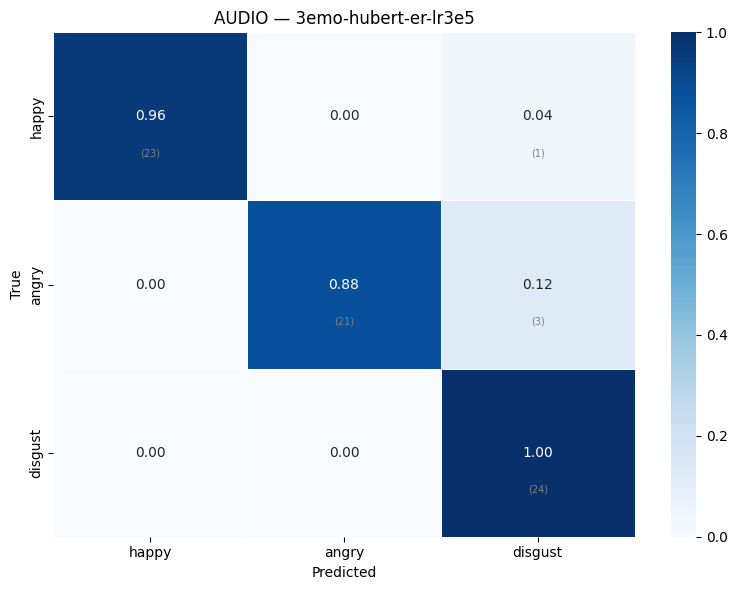

In [14]:
val_audio = EmotionDataset(METADATA, "val", "audio")
audio_loader = DataLoader(val_audio, batch_size=8, shuffle=False, collate_fn=collate_fn)

audio_cfg = next(e for e in EXPERIMENTS if e["name"] == best_audio["name"])
if "hubert" in best_audio["name"]:
    audio_model = HubertForSequenceClassification.from_pretrained(best_audio["path"]).to(DEVICE)
else:
    audio_model = Wav2Vec2ForSequenceClassification.from_pretrained(best_audio["path"]).to(DEVICE)
audio_processor = Wav2Vec2FeatureExtractor.from_pretrained(best_audio["path"])
audio_prep = partial(prepare_audio, processor=audio_processor,
                     window_s=audio_cfg.get("window_s", 3.0), device=DEVICE)

print(f"Evaluating: {best_audio['name']} (F1={best_audio['best_f1']:.4f})")
a_preds, a_labels, a_losses = collect_predictions(audio_model, audio_loader, audio_prep)
a_f1 = per_emotion_report(a_preds, a_labels, a_losses, f"AUDIO — {best_audio['name']}")

del audio_model
torch.cuda.empty_cache()

Evaluating: 3emo-tsf-lr3e5-16f-nf (F1=0.9861)

  VIDEO — 3emo-tsf-lr3e5-16f-nf

              precision    recall  f1-score   support

       happy      0.960     1.000     0.980        24
       angry      1.000     0.958     0.979        24
     disgust      1.000     1.000     1.000        24

    accuracy                          0.986        72
   macro avg      0.987     0.986     0.986        72
weighted avg      0.987     0.986     0.986        72

Emotion          N    Acc     F1  AvgLoss
----------------------------------------
happy           24  1.000  0.980    0.075
angry           24  0.958  0.979    0.261
disgust         24  1.000  1.000    0.083

Weakest: angry (0.979) < happy (0.980) < disgust (1.000)


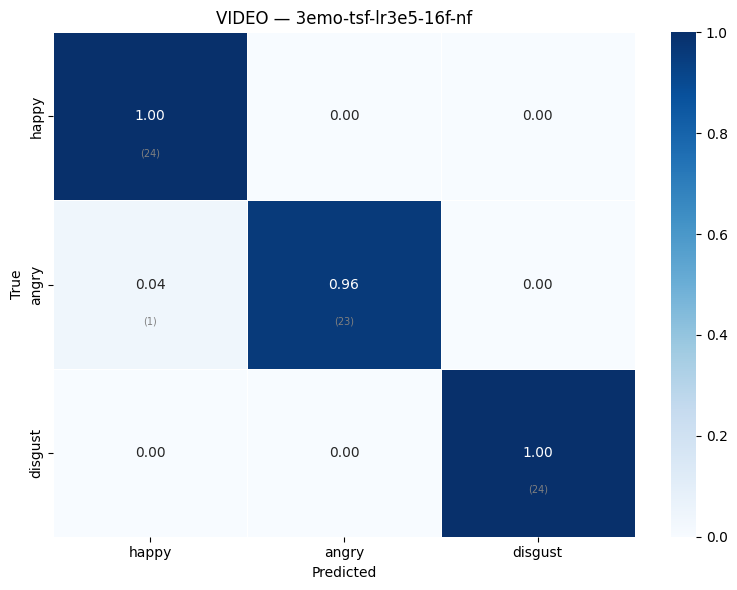

In [15]:
val_video = EmotionDataset(METADATA, "val", "video")
video_loader = DataLoader(val_video, batch_size=2, shuffle=False, collate_fn=collate_fn)

video_cfg = next(e for e in EXPERIMENTS if e["name"] == best_video["name"])
video_model = TimesformerForVideoClassification.from_pretrained(best_video["path"]).to(DEVICE)
video_processor = AutoImageProcessor.from_pretrained(best_video["path"])
video_prep = partial(prepare_video, processor=video_processor,
                     n_frames=video_cfg.get("n_frames", 16), device=DEVICE)

print(f"Evaluating: {best_video['name']} (F1={best_video['best_f1']:.4f})")
v_preds, v_labels, v_losses = collect_predictions(video_model, video_loader, video_prep)
v_f1 = per_emotion_report(v_preds, v_labels, v_losses, f"VIDEO — {best_video['name']}")

del video_model
torch.cuda.empty_cache()

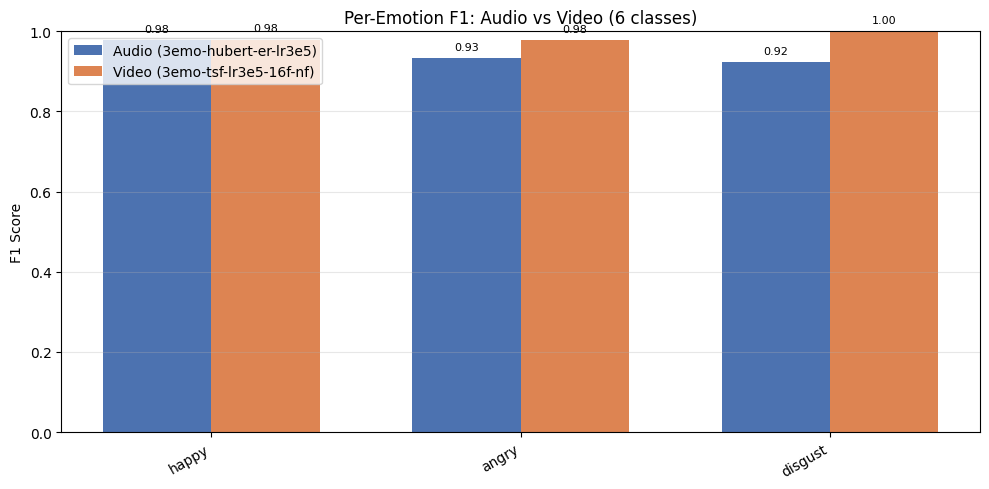


CROSS-MODAL GAPS
Emotion       Audio F1  Video F1     Gap
------------------------------------------
happy            0.979     0.980   0.001 (V)
angry            0.933     0.979   0.045 (V)
disgust          0.923     1.000   0.077 (V)

Overall weighted F1 — Audio: 0.9450, Video: 0.9861


In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(NUM_EMOTIONS)
w = 0.35

ax.bar(x - w/2, a_f1, w, label=f"Audio ({best_audio['name']})", color="#4C72B0")
ax.bar(x + w/2, v_f1, w, label=f"Video ({best_video['name']})", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(EMOTIONS, rotation=30, ha="right")
ax.set_ylabel("F1 Score")
ax.set_title("Per-Emotion F1: Audio vs Video (6 classes)")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
for i in x:
    ax.text(i - w/2, a_f1[i] + 0.02, f"{a_f1[i]:.2f}", ha="center", fontsize=8)
    ax.text(i + w/2, v_f1[i] + 0.02, f"{v_f1[i]:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("CROSS-MODAL GAPS")
print(f"{'='*60}")
print(f"{'Emotion':<12s} {'Audio F1':>9s} {'Video F1':>9s} {'Gap':>7s}")
print("-" * 42)
for i, emo in enumerate(EMOTIONS):
    gap = abs(a_f1[i] - v_f1[i])
    better = "A" if a_f1[i] > v_f1[i] else "V"
    print(f"{emo:<12s} {a_f1[i]:9.3f} {v_f1[i]:9.3f} {gap:7.3f} ({better})")

overall_a = f1_score(a_labels, a_preds, average="weighted")
overall_v = f1_score(v_labels, v_preds, average="weighted")
print(f"\nOverall weighted F1 — Audio: {overall_a:.4f}, Video: {overall_v:.4f}")